<a href="https://colab.research.google.com/github/Soheilp86/Statistical-Machine-Learning/blob/main/41_Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cross-Validation

**Question for today:** you trained a classifier and got 92% on the test set. Does youyr train-test split have any impact on this score? In this notebook we

1. See how the accuracy changes when we only change the split
2. Fix it with **k-fold cross-validation**, and implement it for k-NN
3. Practice on two datasets, one of them **imbalanced**, where we need **stratified** folds

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from sklearn.datasets import make_moons, load_wine, load_breast_cancer
from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                     cross_val_score, cross_validate)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. Change the split, change the accuracy

We use a small noisy dataset (two moons, 300 points) and a k-NN classifier with k = 5. Same data, same model. The **only** thing we change is `random_state`, which decides which points land in the test set.

In [ ]:
X, y = make_moons(n_samples=300, noise=0.35, random_state=0)


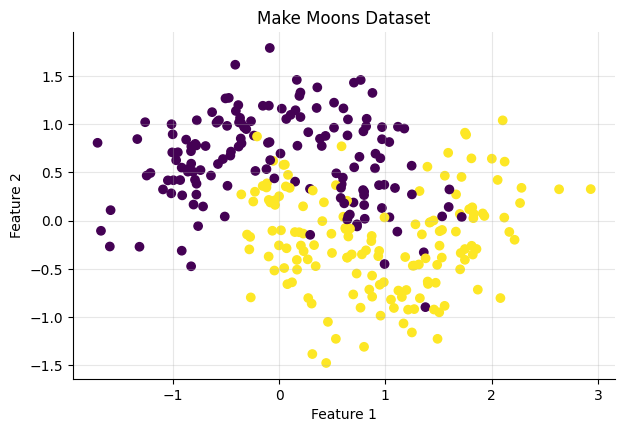

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Make Moons Dataset')
plt.show()

The following cell

1. It splits the dataset into training and testing parts, but uses a different random `seed` each time. This means different data points end up in the test set on each run.
2. It trains a K-Nearest Neighbors model on the training data.
3. It calculates and prints the accuracy on the test data.

**The takeaway:** The exact same model gets different accuracy scores simply because the random split of the data changed.

In [ ]:
for seed in range(5):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=seed)
    acc = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr).score(X_te, y_te)
    print(f"random_state = {seed}:  test accuracy = {acc:.3f}")

random_state = 0:  test accuracy = 0.893
random_state = 1:  test accuracy = 0.867
random_state = 2:  test accuracy = 0.933
random_state = 3:  test accuracy = 0.880
random_state = 4:  test accuracy = 0.920


Five splits, five different answers. How big is the effect? Repeat with 100 splits:

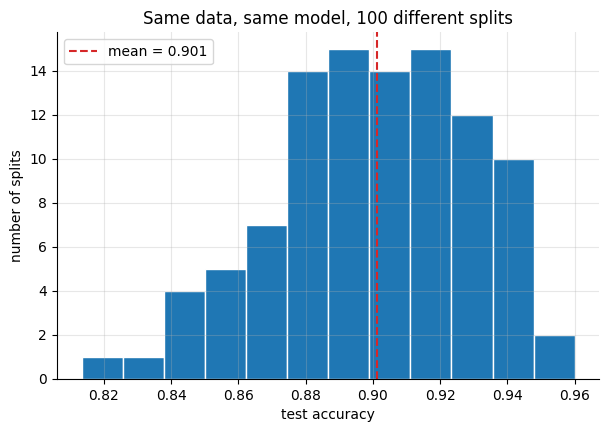

min = 0.813   max = 0.960   std = 0.032


In [ ]:
accs = []
for seed in range(100):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=seed)
    accs.append(KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr).score(X_te, y_te))
accs = np.array(accs)

plt.hist(accs, bins=12, color="#1f77b4", edgecolor="white")
plt.axvline(accs.mean(), color="#d62728", ls="--", label=f"mean = {accs.mean():.3f}")
plt.xlabel("test accuracy"); plt.ylabel("number of splits"); plt.legend()
plt.title("Same data, same model, 100 different splits"); plt.show()
print(f"min = {accs.min():.3f}   max = {accs.max():.3f}   std = {accs.std():.3f}")

The accuracy ranges over about 15 points. A single split is one random draw from this histogram, so **which number is "the" accuracy?**

## 2.General case! k-fold cross-validation

1. Split the training data into **K folds** (here K = 5).
2. For each fold: train on the other K − 1 folds, score on this fold.
3. Average the K scores (and look at their spread).

$$\text{CV score} = \frac{1}{K}\sum_{i=1}^{K} \text{score}_i$$

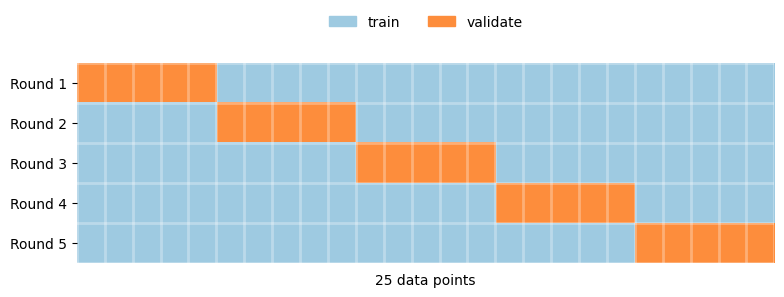

In [ ]:
def plot_kfold(n_samples=25, n_splits=5):
    grid = np.zeros((n_splits, n_samples))
    for i, (_, val) in enumerate(KFold(n_splits).split(np.arange(n_samples))):
        grid[i, val] = 1
    fig, ax = plt.subplots(figsize=(9, 2.6))
    ax.imshow(grid, cmap=ListedColormap(["#9ecae1", "#fd8d3c"]), aspect="auto")
    ax.set_xticks(np.arange(-.5, n_samples, 1), minor=True); ax.set_yticks(np.arange(-.5, n_splits, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2); ax.grid(which="major", visible=False)
    ax.tick_params(which="minor", length=0)
    ax.set_yticks(range(n_splits)); ax.set_yticklabels([f"Round {i+1}" for i in range(n_splits)])
    ax.set_xticks([]); ax.set_xlabel(f"{n_samples} data points")
    ax.legend(handles=[Patch(color="#9ecae1", label="train"), Patch(color="#fd8d3c", label="validate")],
              loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=2, frameon=False)
    for s in ax.spines.values(): s.set_visible(False)
    plt.show()

plot_kfold()

## 3. Implementation with k-NN

First rule: **lock away a test set** before any experiments. All CV happens on the training part.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print(len(X_train), "training points,", len(X_test), "locked-away test points")

225 training points, 75 locked-away test points


### 3.1 By hand: a loop, a split, a fit, a score

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    model = KNeighborsClassifier(n_neighbors=5)
    model.fit(X_train[train_idx], y_train[train_idx])            # train on 4 folds
    acc = model.score(X_train[val_idx], y_train[val_idx])        # validate on the 5th
    fold_scores.append(acc)
    print(f"Fold {fold}: train on {len(train_idx)}, validate on {len(val_idx)}  ->  accuracy {acc:.3f}")

print(f"\nCV accuracy = {np.mean(fold_scores):.3f} ± {np.std(fold_scores):.3f}")

Fold 1: train on 180, validate on 45  ->  accuracy 0.933
Fold 2: train on 180, validate on 45  ->  accuracy 0.911
Fold 3: train on 180, validate on 45  ->  accuracy 0.933
Fold 4: train on 180, validate on 45  ->  accuracy 0.844
Fold 5: train on 180, validate on 45  ->  accuracy 0.844

CV accuracy = 0.893 ± 0.041


### 3.2 The one-liner

`cross_val_score` does the whole loop. With the same folds it gives identical numbers:

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)

scores = cross_val_score(KNeighborsClassifier(n_neighbors=5), X_train, y_train, cv=kf)
print("scores:", scores.round(3), "  same as our loop:", np.allclose(scores, fold_scores))
print(f"CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}")

scores: [0.933 0.911 0.933 0.844 0.844]   same as our loop: True
CV accuracy = 0.893 ± 0.041


### 3.3 We can use CV to find what the best k in KNN classification.


Idea: Test out many different settings for our model (trained on train not test)using Cross-Validation to find out which one works best.


**Why:not test** If you use your final test set over and over to pick the best `k`, you are essentially "cheating" and the model indirectly learns the test set. The test set must remain completely unseen till the end.


**steps**

1. **set aside the test set** entirely.
2. **Use CV** on your training data to try out different values (e.g., k=1, k=3, k=5...).
3. **Pick the best `k`** that gives the highest average CV score.
4. **Test once:** Train your final model using that winning `k` on all training data, and then test it on your test set exactly *once*.

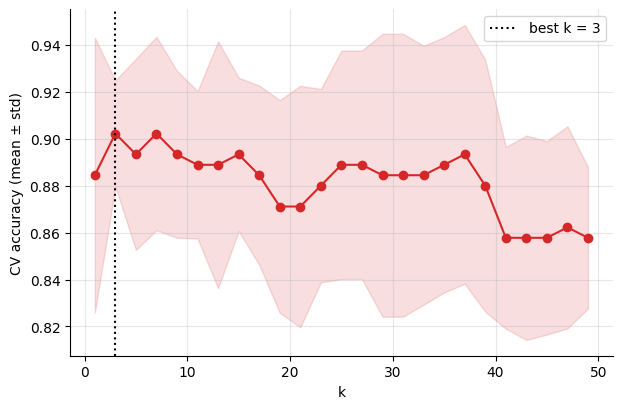

CV accuracy of best k : 0.902
Test accuracy (once)  : 0.893


In [ ]:
# from 1 to 50 go 2 by 2 to select k: 1, 3, 5, ...
ks = list(range(1, 50, 2))



means, stds = [], []


for k in ks:
    s = cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=kf)

    means.append(s.mean()); stds.append(s.std())

means, stds = np.array(means), np.array(stds)

best_k = ks[int(np.argmax(means))]

plt.plot(ks, means, "o-", color="#d62728")
plt.fill_between(ks, means - stds, means + stds, color="#d62728", alpha=0.15)
plt.axvline(best_k, color="k", ls=":", label=f"best k = {best_k}")
plt.xlabel("k"); plt.ylabel("CV accuracy (mean ± std)"); plt.legend(); plt.show()

final = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
print(f"CV accuracy of best k : {means.max():.3f}")
print(f"Test accuracy (once)  : {final.score(X_test, y_test):.3f}")

Moons has balanced classes, so plain `KFold` was fine. Next we see when it is **not**.

## 4. Your turn: two datasets

Both use the same scaled k-NN model. (k-NN uses distances, so features must be on the same scale. Putting `StandardScaler` inside the pipeline re-fits it on each training fold, so nothing leaks from the validation fold.)

In [ ]:
knn_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))

### Dataset A: Wine (easy)
178 wines, 13 chemical measurements, 3 classes.

In [ ]:
X_wine, y_wine = load_wine(return_X_y=True)
print("shape:", X_wine.shape, "  class counts:", np.bincount(y_wine))

shape: (178, 13)   class counts: [59 71 48]


In [ ]:
# Do a basic EDA: get info about this dataset, what are features? distribution of classes, .... if you can plot it.

**A1.** Repeat Part 1: run 10 different `random_state` values with a 75/25 split and print each test accuracy.

In [ ]:
for seed in range(10):
    # YOUR CODE HERE: split, fit knn_pipe, print the test accuracy
    pass

**A2.** Now get the 5-fold CV accuracy (mean ± std). Use `KFold(5, shuffle=True, random_state=0)`.
*Why `shuffle=True`?* The rows of the Wine file are sorted by class. Without shuffling, each fold would contain only one or two classes.

In [ ]:
# YOUR CODE HERE: use cross_val_score with knn_pipe and print mean ± std

**A3.** Find the best `k` from 1 to 30 by CV. Plot CV accuracy against `k`. (For this exercise use all the data; in a real project you would keep a test set.)

In [ ]:
ks = range(1, 31)
# YOUR CODE HERE: for each k, build make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
# compute its CV accuracy, then plot and print the best k

**Think about it:** (a) How does the spread of the single-split accuracies (A1) compare with the fold-to-fold std (A2)? (b) Is the curve in A3 sharply peaked or flat? What does that tell you about how carefully `k` needs to be chosen?

## Dataset B: rare malignant tumors (imbalanced)
We take the breast-cancer data, keep all 357 benign tumors but only **20 malignant** ones. The class we care about (`1` = malignant) is rare.

In [ ]:
cancer = load_breast_cancer()
rng = np.random.default_rng(0)
benign = np.where(cancer.target == 1)[0]
malignant = rng.choice(np.where(cancer.target == 0)[0], size=20, replace=False)
keep = np.concatenate([benign, malignant])

X_imb = cancer.data[keep]
y_imb = (cancer.target[keep] == 0).astype(int)          # 1 = malignant (rare), 0 = benign


In [ ]:
# do a basic EDA first. Underestand the data set, size, class distribution.

In [ ]:
#apply knn-classification. What is accuracy?

In [ ]:
#run knn with CV

Accuracy will look great on this data even for a useless model. Take a moment and answer why?

Track **recall**: the fraction of malignant tumors we actually catch.

Run plain shuffled `KFold` and look at how many malignant cases each validation fold gets.

Something is off! Isn't it? To fix this we can use `StratifiedKFold`. Do a alittle research and learn what it is and how to implement.

In [ ]:
# YOUR CODE HERE

## Summary

- A single train/test split is **one random draw**; the accuracy changes with the split.
- **K-fold CV** averages over K splits: every point is validated once. Report **mean ± std**.
- Use CV to **choose hyperparameters** (like `k`); then use the test set **once** at the end.
- For **imbalanced classes**, use **`StratifiedKFold`** (each fold keeps the class proportions) and look at **recall / F1**, not just accuracy.
- Put preprocessing (like scaling) **inside a pipeline** so it is fit on training folds only.

```python
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)   # default for classification
scores = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(5)), X, y, cv=cv)
```